## feature selection : Recursive Feature Elimination (RFE)

중요도가 낮은 Feature를 차례대로 제거함

make_classification 임의로 분류 데이터 샘플링

step=1 1개씩 제거하면서 진행 (25, 24, 23, ...)

verbose=2 순차적으로 함축 정보 출력

cross-validation : 모델의 일반화성능을 추정하기위한 지표. 모델 성능 평가 결과의 편향을 방지하기 위해 여러개의 fold로 나누어 각각을 test data로 사용하는 교차검증 방법.

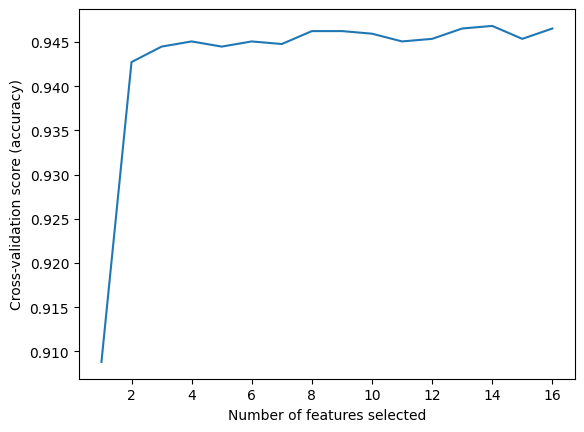

Selected Features:
Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'Residence_type', 'avg_glucose_level', 'bmi', 'Govt_job', 'Private',
       'Self-employed', 'formerly smoked', 'never smoked', 'smokes'],
      dtype='object')
Excluded Features:
Index(['Never_worked', 'children'], dtype='object')


In [ ]:
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestClassifier

# 데이터를 특성(X)과 타겟(y)으로 분할
X = data.drop('stroke', axis=1)
y = data['stroke']

# 랜덤 포레스트 분류기 객체 생성
rf_classifier = RandomForestClassifier()

# RFECV 객체 생성
rfecv = RFECV(estimator=rf_classifier, step=1, cv=5, scoring='accuracy')

# RFECV로 feature selection 수행
rfecv.fit(X, y)

# 각 특성별로의 Cross-validation scores
cv_scores = rfecv.cv_results_['mean_test_score']

# 특성의 개수에 따른 Cross-validation scores의 변화를 시각화
plt.figure()
plt.xlabel("Number of features selected")
plt.ylabel("Cross-validation score (accuracy)")
plt.plot(range(1, len(cv_scores) + 1), cv_scores)
plt.show()

# 선택된 변수 출력
selected_features = X.columns[rfecv.support_]
print("Selected Features:")
print(selected_features)

# 선택되지 않은 변수 출력
excluded_features = X.columns[~rfecv.support_]
print("Excluded Features:")
print(excluded_features)

## feature seleciton : SelectFromModel(LASSO)

위에 방법이랑 마찬가지로 적절한 cv값

LASSO 회귀는 손실 함수에 L1 규제항을 추가하여 모델의 가중치(회귀 계수)를 제한합니다. L1 규제는 가중치의 절댓값에 비례하는 패널티를 부여하여 일부 가중치를 0으로 만듭니다. 따라서, LASSO 회귀는 변수 선택 기능을 수행하며, 중요하지 않은 변수의 가중치를 0으로 만들어 제거합니다.

LASSO 회귀 모델에서 회귀 계수는 각 변수가 예측 결과에 어떤 영향을 주는지를 나타냅니다. 회귀 계수는 해당 변수의 영향력과 방향(양수 또는 음수)을 결정합니다.

일반적으로, 회귀 계수의 절댓값이 클수록 해당 변수는 예측 결과에 큰 영향을 주는 것으로 해석됩니다. 양수인 경우 해당 변수가 예측 결과를 증가시키는 방향으로 영향을 주고, 음수인 경우 해당 변수가 예측 결과를 감소시키는 방향으로 영향을 줍니다.

회귀 계수의 크기는 변수의 중요도를 평가하는 데 사용될 수 있습니다. LASSO 회귀는 변수 선택을 수행하기 때문에, 중요한 변수는 0이 아닌 회귀 계수를 가지게 되고, 중요하지 않은 변수는 0의 회귀 계수를 가지게 됩니다.

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:617: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0, tolerance: 0.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:617: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0, tolerance: 0.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:617: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0, tolerance: 0.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:617: ConvergenceWarning: Objective did not converge. You might want to increase the number of iteration

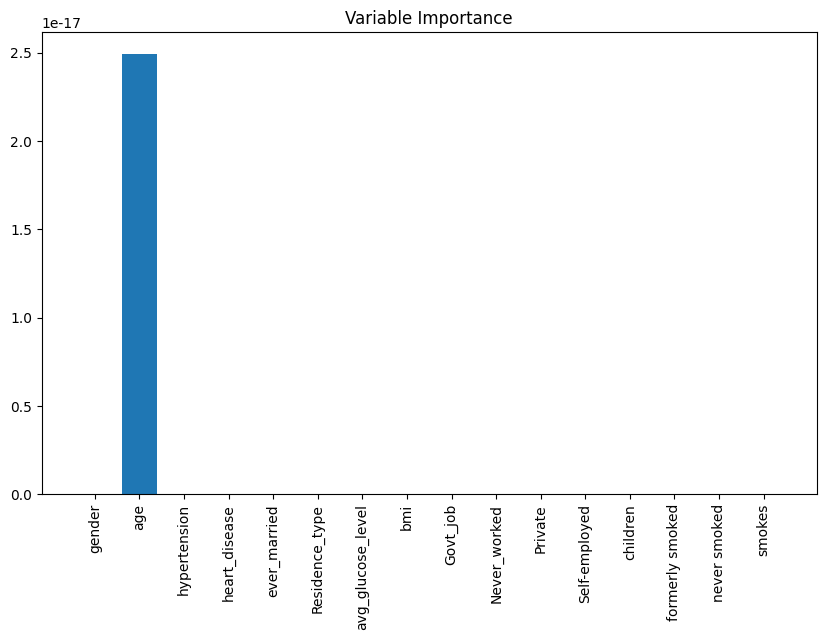

In [ ]:
from sklearn.linear_model import LassoCV
import matplotlib.pyplot as plt

# 데이터를 특성(X)과 타겟(y)으로 분할
X = data.drop('stroke', axis=1)
y = data['stroke']

# LassoCV 모델 생성
lasso = LassoCV(cv=5)

# Lasso 회귀 모델 학습
lasso.fit(X, y)

# 변수 중요도 추출
importances = np.abs(lasso.coef_)

# 변수 중요도 시각화
plt.figure(figsize=(10, 6))
plt.title("Variable Importance")
plt.bar(range(X.shape[1]), importances)
plt.xticks(range(X.shape[1]), X.columns, rotation=90)
plt.show()

## feature selection : 변수 중요도 (permutation-feature importance)

 모델링 알고리즘에서 계산되는 변수의 상대적 중요성을 측정하는 방법

 중요도가 높은 순서로 변수를 선택하거나 임계값을 설정하여 선택할 수 있습니다.

 특성을 무작위로 섞어서 성능에 미치는 영향을 평가하는 방법입니다. 특성을 섞은 후 모델의 성능 변화를 측정하여, 특성의 중요도를 계산합니다. 이 방법은 모델의 예측 성능에 어떤 특성이 가장 큰 영향을 미치는지 확인하는 데 유용합니다.

 * 왜 Feature Importance는 절대적인 Feature Selection 기준이 될 수 없는가?
 https://velog.io/@gangjoo/ML-%EB%B6%84%EB%A5%98-Feature-Selection
 

In [ ]:
!pip install eli5
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import eli5
from eli5.sklearn import PermutationImportance

# 데이터셋을 특성과 타겟 변수로 분할
X = data.drop('stroke', axis=1)
y = data['stroke']

# RandomForestClassifier 객체 생성
rf_classifier = RandomForestClassifier()

# 데이터셋을 훈련 세트와 검증 세트로 분할
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# RandomForestClassifier 학습
rf_classifier.fit(X_train, y_train)

# Permutation Importance 계산
perm_importance = PermutationImportance(rf_classifier, random_state=42).fit(X_train, y_train)

# 훈련 데이터의 permutation importance 확인
eli5.show_weights(perm_importance, feature_names=X_train.columns.tolist())

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.2/216.2 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for eli5: filename=eli5-0.13.0-py2.py3-none-any.whl size=107730 sha256=996517c62d0aafe8d79a5225df5489925ac7007cc62c9af99721b9d8f15654db
  Stored in directory: /root/.cache/pip/wheels/b8/58/ef/2cf4c306898c2338d51540e0922c8e0d6028e07007085c0004
Successfully built eli5


Weight,Feature
0.0456 ± 0.0034,age
0.0408 ± 0.0022,avg_glucose_level
0.0364 ± 0.0033,bmi
0.0188 ± 0.0044,Residence_type
0.0177 ± 0.0025,hypertension
0.0167 ± 0.0018,never smoked
0.0160 ± 0.0040,gender
0.0140 ± 0.0026,Self-employed
0.0116 ± 0.0015,Private
0.0108 ± 0.0018,smokes


feature weight가 0 : 모델의 예측에 아무 영향을 주지 않는다. target 변수와의 선형관계가 존재하지 않는다.

# 언더샘플링 모델 성능 평가
## 1. RandomUnderSampler

In [ ]:
y.value_counts()

0    3242
1     180
Name: stroke, dtype: int64

In [ ]:
from imblearn.under_sampling import RandomUnderSampler


# 언더샘플링 수행
rus = RandomUnderSampler(random_state=42)
x_resampled_rus, y_resampled_rus = rus.fit_resample(X, y)

y_count = y_resampled_rus.value_counts()

# 언더샘플링된 데이터 확인
print(y_count)

0    180
1    180
Name: stroke, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier


# 최적의 파라미터: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
# 최적의 점수: 0.9067809038252388

# train, test 데이터셋 분리
x_train, x_test, y_train, y_test = train_test_split(x_resampled_rus, y_resampled_rus, test_size=0.3, random_state=42)
# test_size : test 데이터와 train 데이터의 비율
# random_state : 매번 결과가 같게 해줌( 시드 설정)


# 랜덤 포레스트 모델 생성하기
random_forest = RandomForestClassifier(n_estimators=300, 
                                       min_samples_split = 2,
                                       min_samples_leaf= 1,
                                       random_state=42)        # n_estimators=300 300개의 나무를 생성하겠다

# 모델 훈련하기
random_forest.fit(x_train, y_train)

# 예측하기
y_pred = random_forest.predict(x_test)

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score

# 정확도 계산
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# 정밀도 계산
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

# 재현율 계산
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Accuracy: 0.7870370370370371
Precision: 0.7419354838709677
Recall: 0.8679245283018868


## RandomUnderSampler - bootstrap

In [ ]:
# 부트스트랩 함수 정의
def bootstrap_sampling(x_train, y_train):
    n_samples = len(x_train)
    indices = np.random.choice(range(n_samples), size=n_samples, replace=True)
    x_boot = x_train.iloc[indices]
    y_boot = y_train.iloc[indices]
    return x_boot, y_boot

# 언더샘플링 방법에 따른 성능 비교
n_bootstrap = 100  # 부트스트랩 횟수

accuracy_scores = []
precision_scores = []
recall_scores = []

for _ in range(n_bootstrap):
    x_boot, y_boot = bootstrap_sampling(x_train, y_train)
    random_forest.fit(x_boot, y_boot)
    y_pred = random_forest.predict(x_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    accuracy_scores.append(accuracy)
    precision_scores.append(precision)
    recall_scores.append(recall)

# 정확도, 정밀도, 재현율 출력
print("Accuracy: {:.4f} ± {:.4f}".format(np.mean(accuracy_scores), np.std(accuracy_scores)))
print("Precision: {:.4f} ± {:.4f}".format(np.mean(precision_scores), np.std(precision_scores)))
print("Recall: {:.4f} ± {:.4f}".format(np.mean(recall_scores), np.std(recall_scores)))

Accuracy: 0.7746 ± 0.0212
Precision: 0.7290 ± 0.0247
Recall: 0.8628 ± 0.0269


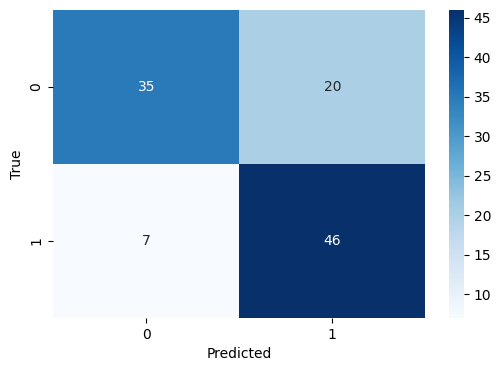

In [ ]:
# Confusion matrix 히트맵 출력
from sklearn.metrics import confusion_matrix

conf_mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## RandomUnderSampler - k-fold 교차검증

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score

# 교차 검증을 위한 StratifiedKFold 객체를 생성합니다.
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# cross_validate 함수를 사용한 교차검증
scoring = ['accuracy', 'precision', 'recall', 'f1']
cv_results = cross_validate(random_forest, x_train, y_train, cv=kfold, scoring=scoring)

# 교차검증 결과 출력
print('Cross-validated scores:')
print("Accuracy: {:.4f} ± {:.4f}".format(cv_results['test_accuracy'].mean(),cv_results['test_accuracy'].std()))
print("Precision: {:.4f} ± {:.4f}".format(cv_results['test_precision'].mean(), cv_results['test_precision'].std()))
print("Recall: {:.4f} ± {:.4f}".format(cv_results['test_recall'].mean(),cv_results['test_recall'].std()))
print("F1-Score: {:.4f} ± {:.4f}".format( cv_results['test_f1'].mean(), cv_results['test_f1'].std()))

Cross-validated scores:
Accuracy: 0.7298 ± 0.0688
Precision: 0.7168 ± 0.0632
Recall: 0.7628 ± 0.0925
F1-Score: 0.7383 ± 0.0735


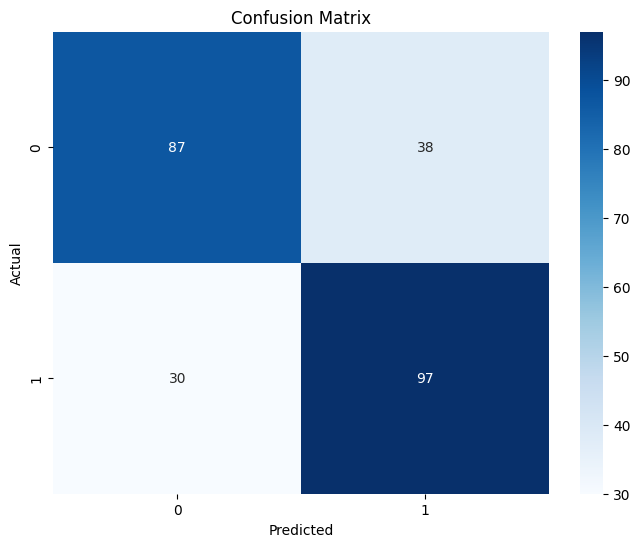

In [ ]:
from sklearn.model_selection import cross_val_predict

# cross_val_predict 함수를 사용한 교차검증 예측 결과
y_pred_cv = cross_val_predict(random_forest, x_train, y_train, cv=kfold)

# 혼동행렬 시각화
cm_cv = confusion_matrix(y_train, y_pred_cv)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cv, annot=True, cmap='Blues', fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## RandomUnderSampler - ROC curve

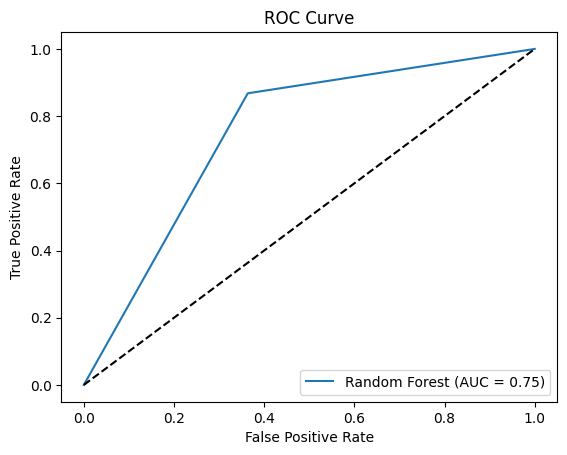

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# ROC curve를 계산합니다
fpr_rus, tpr_rus, thresholds = roc_curve(y_test, y_pred)

# AUC를 계산합니다
auc_rus = roc_auc_score(y_test, y_pred)

# ROC curve를 그립니다
plt.plot(fpr_rus, tpr_rus, label='Random Forest (AUC = %0.2f)' % auc_rus)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

## 2. Nearmiss-1

In [ ]:
from imblearn.under_sampling import NearMiss

# 데이터와 레이블을 준비 (X: 독립변수, y: 종속변수)
x_resampled_ns1, y_resampled_ns1 = NearMiss(version=1).fit_resample(X, y)

y_resampled_ns1.value_counts()

0    180
1    180
Name: stroke, dtype: int64

In [ ]:
# train, test 데이터셋 분리
x_train, x_test, y_train, y_test = train_test_split(x_resampled_ns1, y_resampled_ns1, test_size=0.3, random_state=42)
# test_size : test 데이터와 train 데이터의 비율
# random_state : 매번 결과가 같게 해줌( 시드 설정)


# 랜덤 포레스트 모델 생성하기
random_forest = RandomForestClassifier(n_estimators=300, 
                                       min_samples_split = 2,
                                       min_samples_leaf= 1,
                                       random_state=42)        # n_estimators=300 300개의 나무를 생성하겠다

# 모델 훈련하기
random_forest.fit(x_train, y_train)

# 예측하기
y_pred = random_forest.predict(x_test)

# 정확도 계산
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# 정밀도 계산
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

# 재현율 계산
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Accuracy: 0.7870370370370371
Precision: 0.8260869565217391
Recall: 0.7169811320754716


##  Nearmiss-1 - bootstrap

In [ ]:
# 부트스트랩 함수 정의
def bootstrap_sampling(x_train, y_train):
    n_samples = len(x_train)
    indices = np.random.choice(range(n_samples), size=n_samples, replace=True)
    x_boot = x_train.iloc[indices]
    y_boot = y_train.iloc[indices]
    return x_boot, y_boot

# 언더샘플링 방법에 따른 성능 비교
n_bootstrap = 100  # 부트스트랩 횟수

accuracy_scores = []
precision_scores = []
recall_scores = []

for _ in range(n_bootstrap):
    x_boot, y_boot = bootstrap_sampling(x_train, y_train)
    random_forest.fit(x_boot, y_boot)
    y_pred = random_forest.predict(x_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    accuracy_scores.append(accuracy)
    precision_scores.append(precision)
    recall_scores.append(recall)

# 정확도, 정밀도, 재현율 출력
print("Accuracy: {:.4f} ± {:.4f}".format(np.mean(accuracy_scores), np.std(accuracy_scores)))
print("Precision: {:.4f} ± {:.4f}".format(np.mean(precision_scores), np.std(precision_scores)))
print("Recall: {:.4f} ± {:.4f}".format(np.mean(recall_scores), np.std(recall_scores)))

Accuracy: 0.7760 ± 0.0244
Precision: 0.7971 ± 0.0387
Recall: 0.7323 ± 0.0328


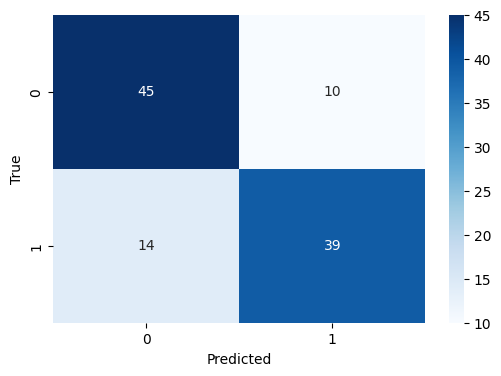

In [ ]:
# Confusion matrix 히트맵 출력
conf_mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## Nearmiss-1 - k-fold 교차검증

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score

# 교차 검증을 위한 StratifiedKFold 객체를 생성합니다.
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# cross_validate 함수를 사용한 교차검증
scoring = ['accuracy', 'precision', 'recall', 'f1']
cv_results = cross_validate(random_forest, x_train, y_train, cv=kfold, scoring=scoring)

# 교차검증 결과 출력
print('Cross-validated scores:')
print("Accuracy: {:.4f} ± {:.4f}".format(cv_results['test_accuracy'].mean(),cv_results['test_accuracy'].std()))
print("Precision: {:.4f} ± {:.4f}".format(cv_results['test_precision'].mean(), cv_results['test_precision'].std()))
print("Recall: {:.4f} ± {:.4f}".format(cv_results['test_recall'].mean(),cv_results['test_recall'].std()))
print("F1-Score: {:.4f} ± {:.4f}".format( cv_results['test_f1'].mean(), cv_results['test_f1'].std()))

Cross-validated scores:
Accuracy: 0.7499 ± 0.0592
Precision: 0.7687 ± 0.0684
Recall: 0.7243 ± 0.0564
F1-Score: 0.7451 ± 0.0579


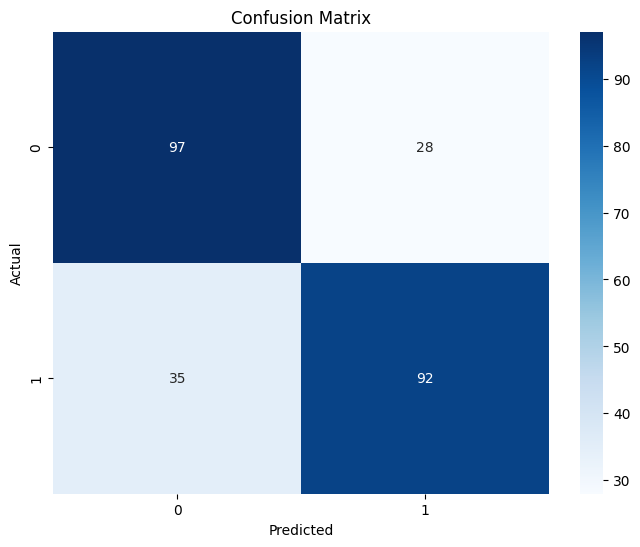

In [ ]:
# cross_val_predict 함수를 사용한 교차검증 예측 결과
y_pred_cv = cross_val_predict(random_forest, x_train, y_train, cv=kfold)

# 혼동행렬 시각화
cm_cv = confusion_matrix(y_train, y_pred_cv)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cv, annot=True, cmap='Blues', fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Nearmiss-1 ROC curve

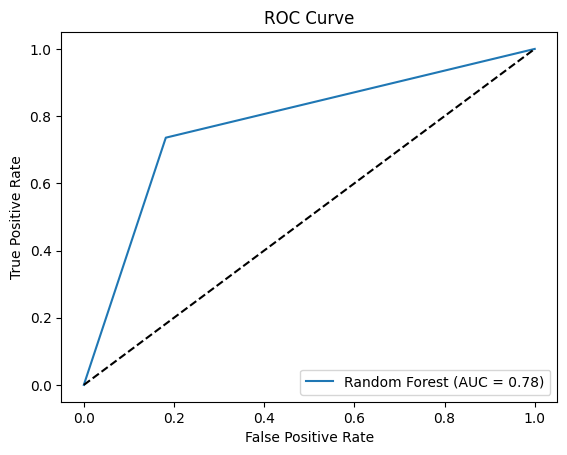

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# ROC curve를 계산합니다
fpr_ns1, tpr_ns1, thresholds = roc_curve(y_test, y_pred)

# AUC를 계산합니다
auc_ns1 = roc_auc_score(y_test, y_pred)

# ROC curve를 그립니다
plt.plot(fpr_ns1, tpr_ns1, label='Random Forest (AUC = %0.2f)' % auc_ns1)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

## 3. Nearmiss-2

In [ ]:
# 데이터와 레이블을 준비 (X: 독립변수, y: 종속변수)
from imblearn.under_sampling import NearMiss
x_resampled_ns2, y_resampled_ns2 = NearMiss(version=2).fit_resample(X, y)

y_resampled_ns2.value_counts()

0    180
1    180
Name: stroke, dtype: int64

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score

# train, test 데이터셋 분리
x_train, x_test, y_train, y_test = train_test_split(x_resampled_ns2, y_resampled_ns2, test_size=0.3, random_state=42)
# test_size : test 데이터와 train 데이터의 비율
# random_state : 매번 결과가 같게 해줌( 시드 설정)


# 랜덤 포레스트 모델 생성하기
random_forest = RandomForestClassifier(n_estimators=300, 
                                       min_samples_split = 2,
                                       min_samples_leaf= 1,
                                       random_state=42)        # n_estimators=300 300개의 나무를 생성하겠다

# 모델 훈련하기
random_forest.fit(x_train, y_train)

# 예측하기
y_pred = random_forest.predict(x_test)

# 정확도 계산
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# 정밀도 계산
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

# 재현율 계산
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Accuracy: 0.8703703703703703
Precision: 0.9148936170212766
Recall: 0.8113207547169812


## Nearmiss-2 - bootstrap

In [ ]:
# 부트스트랩 함수 정의
def bootstrap_sampling(x_train, y_train):
    n_samples = len(x_train)
    indices = np.random.choice(range(n_samples), size=n_samples, replace=True)
    x_boot = x_train.iloc[indices]
    y_boot = y_train.iloc[indices]
    return x_boot, y_boot

# 언더샘플링 방법에 따른 성능 비교
n_bootstrap = 100  # 부트스트랩 횟수

accuracy_scores = []
precision_scores = []
recall_scores = []

for _ in range(n_bootstrap):
    x_boot, y_boot = bootstrap_sampling(x_train, y_train)
    random_forest.fit(x_boot, y_boot)
    y_pred = random_forest.predict(x_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    accuracy_scores.append(accuracy)
    precision_scores.append(precision)
    recall_scores.append(recall)

# 정확도, 정밀도, 재현율 출력
print("Accuracy: {:.4f} ± {:.4f}".format(np.mean(accuracy_scores), np.std(accuracy_scores)))
print("Precision: {:.4f} ± {:.4f}".format(np.mean(precision_scores), np.std(precision_scores)))
print("Recall: {:.4f} ± {:.4f}".format(np.mean(recall_scores), np.std(recall_scores)))

Accuracy: 0.8462 ± 0.0252
Precision: 0.8975 ± 0.0395
Recall: 0.7770 ± 0.0389


MAE r square

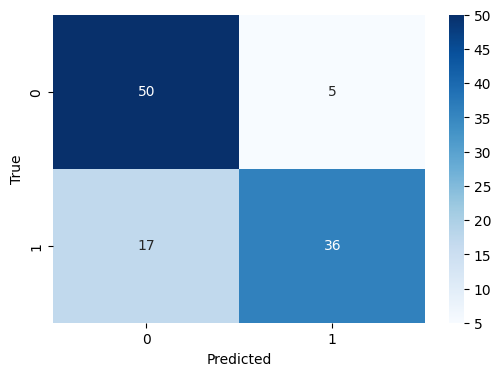

In [ ]:
# Confusion matrix 히트맵 출력
conf_mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## Nearmiss-2 - k-fold 교차검증

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score

# 교차 검증을 위한 StratifiedKFold 객체를 생성합니다.
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# cross_validate 함수를 사용한 교차검증
scoring = ['accuracy', 'precision', 'recall', 'f1']
cv_results = cross_validate(random_forest, x_train, y_train, cv=kfold, scoring=scoring)

# 교차검증 결과 출력
print('Cross-validated scores:')
print("Accuracy: {:.4f} ± {:.4f}".format(cv_results['test_accuracy'].mean(),cv_results['test_accuracy'].std()))
print("Precision: {:.4f} ± {:.4f}".format(cv_results['test_precision'].mean(), cv_results['test_precision'].std()))
print("Recall: {:.4f} ± {:.4f}".format(cv_results['test_recall'].mean(),cv_results['test_recall'].std()))
print("F1-Score: {:.4f} ± {:.4f}".format( cv_results['test_f1'].mean(), cv_results['test_f1'].std()))

Cross-validated scores:
Accuracy: 0.8649 ± 0.0270
Precision: 0.9129 ± 0.0717
Recall: 0.8188 ± 0.0411
F1-Score: 0.8600 ± 0.0220


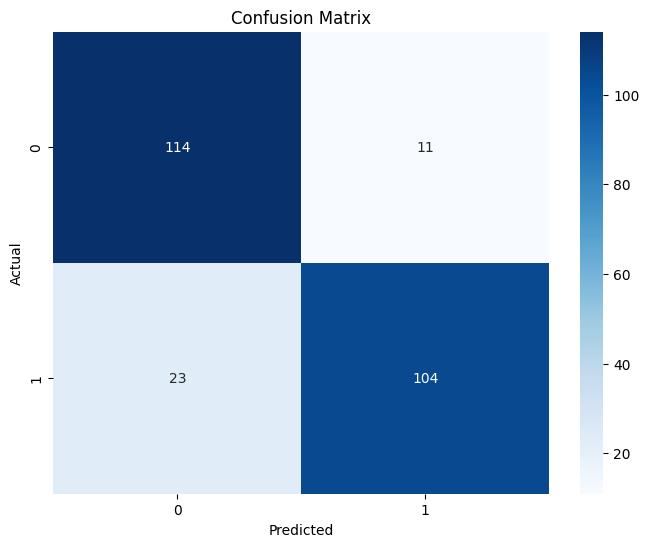

In [ ]:
# cross_val_predict 함수를 사용한 교차검증 예측 결과
y_pred_cv = cross_val_predict(random_forest, x_train, y_train, cv=kfold)

# 혼동행렬 시각화
cm_cv = confusion_matrix(y_train, y_pred_cv)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cv, annot=True, cmap='Blues', fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Nearmiss-2 ROC curve

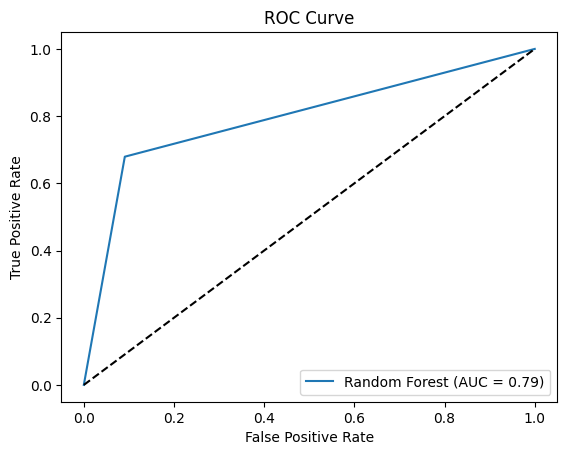

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# ROC curve를 계산합니다
fpr_ns2, tpr_ns2, thresholds = roc_curve(y_test, y_pred)

# AUC를 계산합니다
auc_ns2 = roc_auc_score(y_test, y_pred)

# ROC curve를 그립니다
plt.plot(fpr_ns2, tpr_ns2, label='Random Forest (AUC = %0.2f)' % auc_ns2)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

## 4. Nearmiss-3

In [ ]:
# 데이터와 레이블을 준비 (X: 독립변수, y: 종속변수)
x_resampled_ns3, y_resampled_ns3 = NearMiss(version=3).fit_resample(X, y)

y_resampled_ns3.value_counts()

0    180
1    180
Name: stroke, dtype: int64

In [ ]:
# train, test 데이터셋 분리
x_train, x_test, y_train, y_test = train_test_split(x_resampled_ns3, y_resampled_ns3, test_size=0.3, random_state=42)
# test_size : test 데이터와 train 데이터의 비율
# random_state : 매번 결과가 같게 해줌( 시드 설정)


# 랜덤 포레스트 모델 생성하기
random_forest = RandomForestClassifier(n_estimators=300, 
                                       min_samples_split = 2,
                                       min_samples_leaf= 1,
                                       random_state=42)        # n_estimators=300 300개의 나무를 생성하겠다

# 모델 훈련하기
random_forest.fit(x_train, y_train)

# 예측하기
y_pred = random_forest.predict(x_test)

# 정확도 계산
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# 정밀도 계산
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

# 재현율 계산
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Accuracy: 0.6111111111111112
Precision: 0.6
Recall: 0.6226415094339622


## Nearmiss-3 - bootstrap

In [ ]:
# 부트스트랩 함수 정의
def bootstrap_sampling(x_train, y_train):
    n_samples = len(x_train)
    indices = np.random.choice(range(n_samples), size=n_samples, replace=True)
    x_boot = x_train.iloc[indices]
    y_boot = y_train.iloc[indices]
    return x_boot, y_boot

# 언더샘플링 방법에 따른 성능 비교
n_bootstrap = 100  # 부트스트랩 횟수

accuracy_scores = []
precision_scores = []
recall_scores = []

for _ in range(n_bootstrap):
    x_boot, y_boot = bootstrap_sampling(x_train, y_train)
    random_forest.fit(x_boot, y_boot)
    y_pred = random_forest.predict(x_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    accuracy_scores.append(accuracy)
    precision_scores.append(precision)
    recall_scores.append(recall)

# 정확도, 정밀도, 재현율 출력
print("Accuracy: {:.4f} ± {:.4f}".format(np.mean(accuracy_scores), np.std(accuracy_scores)))
print("Precision: {:.4f} ± {:.4f}".format(np.mean(precision_scores), np.std(precision_scores)))
print("Recall: {:.4f} ± {:.4f}".format(np.mean(recall_scores), np.std(recall_scores)))

Accuracy: 0.6163 ± 0.0356
Precision: 0.6073 ± 0.0395
Recall: 0.6262 ± 0.0648


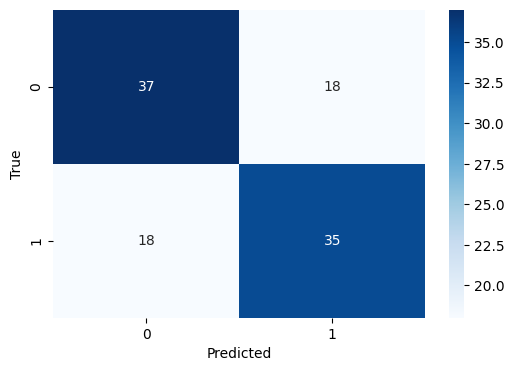

In [ ]:
# Confusion matrix 히트맵 출력
conf_mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## Nearmiss-3 - k-fold 교차검증

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score

# 교차 검증을 위한 StratifiedKFold 객체를 생성합니다.
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# cross_validate 함수를 사용한 교차검증
scoring = ['accuracy', 'precision', 'recall', 'f1']
cv_results = cross_validate(random_forest, x_train, y_train, cv=kfold, scoring=scoring)

# 교차검증 결과 출력
print('Cross-validated scores:')
print("Accuracy: {:.4f} ± {:.4f}".format(cv_results['test_accuracy'].mean(),cv_results['test_accuracy'].std()))
print("Precision: {:.4f} ± {:.4f}".format(cv_results['test_precision'].mean(), cv_results['test_precision'].std()))
print("Recall: {:.4f} ± {:.4f}".format(cv_results['test_recall'].mean(),cv_results['test_recall'].std()))
print("F1-Score: {:.4f} ± {:.4f}".format( cv_results['test_f1'].mean(), cv_results['test_f1'].std()))

Cross-validated scores:
Accuracy: 0.6268 ± 0.0644
Precision: 0.6390 ± 0.0654
Recall: 0.5905 ± 0.0856
F1-Score: 0.6130 ± 0.0736


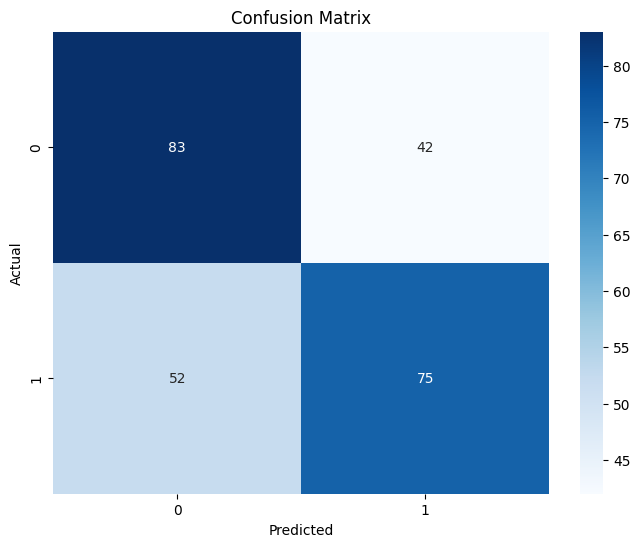

In [ ]:
# cross_val_predict 함수를 사용한 교차검증 예측 결과
y_pred_cv = cross_val_predict(random_forest, x_train, y_train, cv=kfold)

# 혼동행렬 시각화
cm_cv = confusion_matrix(y_train, y_pred_cv)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cv, annot=True, cmap='Blues', fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Nearmiss-3 ROC curve

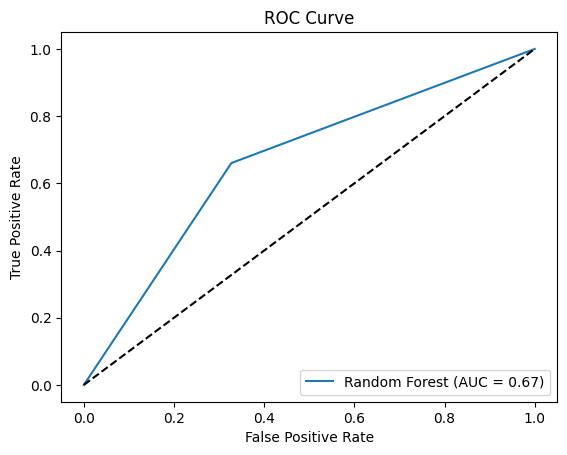

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# ROC curve를 계산합니다
fpr_ns3, tpr_ns3, thresholds = roc_curve(y_test, y_pred)

# AUC를 계산합니다
auc_ns3 = roc_auc_score(y_test, y_pred)

# ROC curve를 그립니다
plt.plot(fpr_ns3, tpr_ns3, label='Random Forest (AUC = %0.2f)' % auc_ns3)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

## ROC Curve : 모델의 효율성 평가
모델의 효율성을 민감도, 특이도를 이용해 그래프로 나타냄.

x축이 이루는 면적의 넓이는 AUC(area under curve)라고 하고, AUC 값이 1에 가까울수록 효율적인 모델. => 면적이 넓을수록 (비선형성이 강할수록) 분류 성능이 좋다

x축 : FPR(false positive rate) 틀린걸 맞았다고 잘못 예측 (FPR = FP / (FP+TN))

y축 : TPR(true positive rate) 맞은걸 맞았다고 맞게 예측 (TPR = TP / (TP + FN) = Recall)

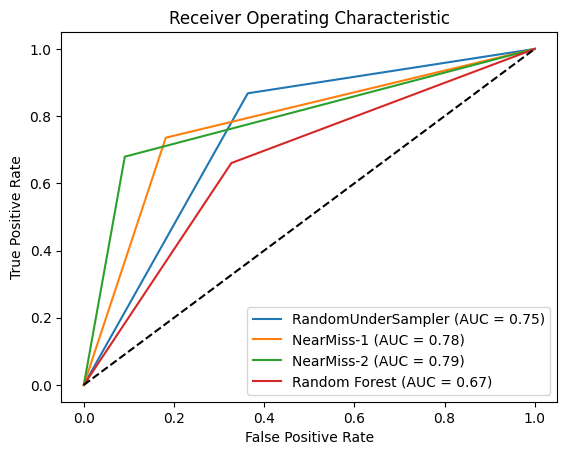

In [ ]:
# RandomUnderSampler의 ROC curve
plt.plot(fpr_rus, tpr_rus, label='RandomUnderSampler (AUC = %0.2f)' % auc_rus)
# Nearmiss-1의 ROC curve
plt.plot(fpr_ns1, tpr_ns1, label='NearMiss-1 (AUC = %0.2f)' % auc_ns1)
# Nearmiss-2의 ROC curve
plt.plot(fpr_ns2, tpr_ns2, label='NearMiss-2 (AUC = %0.2f)' % auc_ns2)
# Nearmiss-3의 ROC curve
plt.plot(fpr_ns3, tpr_ns3, label='Random Forest (AUC = %0.2f)' % auc_ns3)

# 기준선 그리
plt.plot([0, 1], [0, 1], 'k--')

# 축과 범례 설정
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')

# 그래프 출력
plt.show()

# 추가 분석 : feature importance

## 1. Mean Decrease Impurity(Gini Importance)
* RandomForestClassifier의 feature_importances_ 속성을 사용하여 계산됩니다.

장점: 계산이 빠르고, 트리 모델의 불순도 감소에 기반하여 각 feature의 중요도를 추정합니다.

단점: 다중 공선성이 있는 feature에 대해서는 잘 작동하지 않을 수 있습니다.

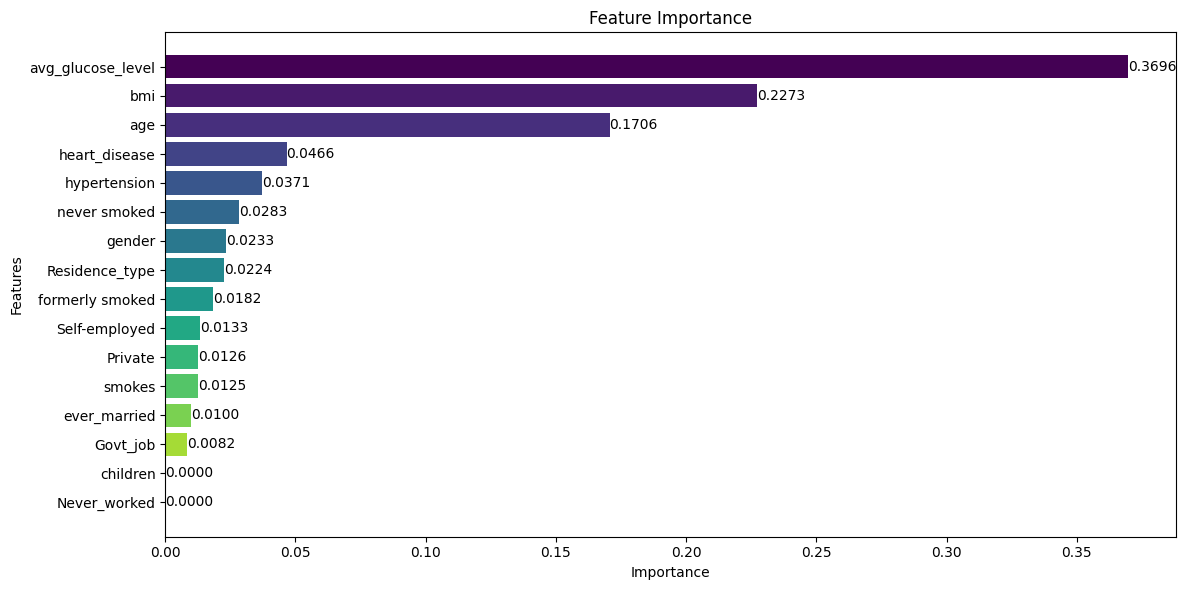

In [ ]:
import matplotlib.pyplot as plt

# 각 feature의 중요도 확인
importances = random_forest.feature_importances_

# 중요도 순서대로 feature의 인덱스 정렬
indices = np.argsort(importances)[::-1]

# 중요도 순서대로 feature 이름과 중요도 추출
feature_names = x_train.columns[indices]
importance_values = importances[indices]

# Bar plot 그리기
plt.figure(figsize=(12, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(feature_names)))
plt.barh(range(x_train.shape[1]), importance_values, color=colors)
plt.yticks(range(x_train.shape[1]), feature_names)
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance')

# 각 값 숫자로 표현
for i, v in enumerate(importance_values):
    plt.text(v, i, f'{v:.4f}', color='black', va='center')

plt.tight_layout()
plt.gca().invert_yaxis()  # 그래프를 뒤집어서 가장 중요한 feature가 위에 그려지도록 함
plt.show()

## 2. Permutation Importance
* eli5 라이브러리의 PermutationImportance 클래스를 사용합니다.

장점: 특정 feature의 중요도를 평가하기 위해 해당 feature를 무작위로 섞어 예측 성능의 변화를 측정합니다. 모델에 의존하지 않고 독립적으로 feature의 중요도를 평가할 수 있습니다.

단점: 계산에 시간이 오래 걸릴 수 있습니다.

In [ ]:
import eli5
from eli5.sklearn import PermutationImportance

# Permutation Importance 계산
perm = PermutationImportance(random_forest, random_state=42).fit(x_train, y_train)

# permutation importance 확인
eli5.show_weights(perm, feature_names=x_train.columns.tolist())

Weight,Feature
0.2317 ± 0.0343,avg_glucose_level
0.0929 ± 0.0205,bmi
0.0587 ± 0.0281,age
0.0143 ± 0.0119,never smoked
0.0127 ± 0.0117,heart_disease
0.0103 ± 0.0147,formerly smoked
0.0032 ± 0.0059,Self-employed
0.0032 ± 0.0032,gender
0.0024 ± 0.0081,hypertension
0.0016 ± 0.0081,Residence_type


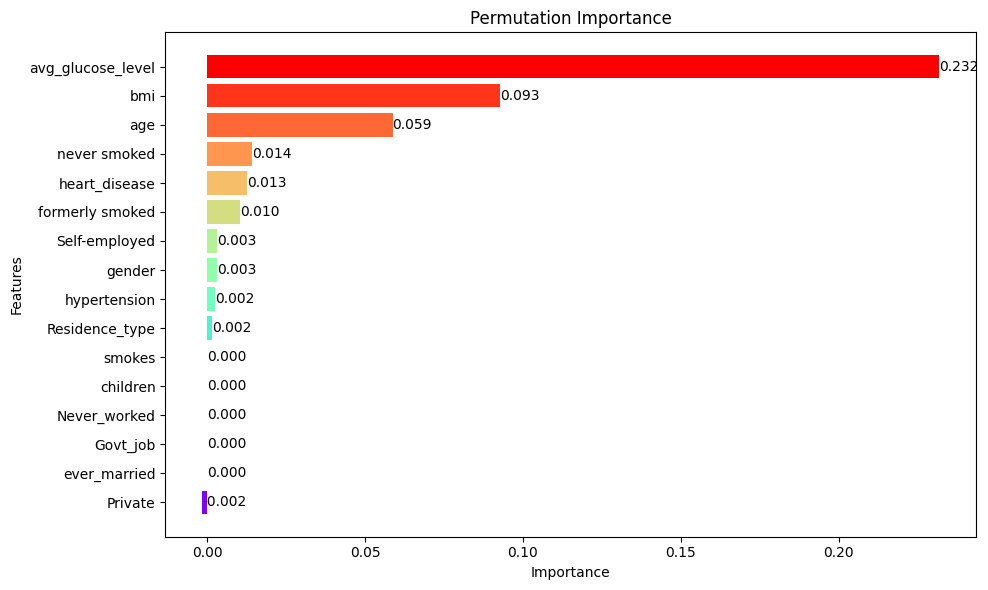

In [ ]:
# 중요도 순서대로 feature 이름과 중요도 추출
feature_names = x_test.columns
importance_values = perm.feature_importances_

# 중요도를 기준으로 feature 정렬
sorted_indices = importance_values.argsort()
sorted_feature_names = feature_names[sorted_indices]
sorted_importance_values = importance_values[sorted_indices]

# 무지개 색상 리스트 생성
colors = plt.cm.rainbow(np.linspace(0, 1, len(sorted_feature_names)))

# Bar plot 그리기
plt.figure(figsize=(10, 6))
plt.barh(range(x_test.shape[1]), sorted_importance_values, color=colors)
plt.yticks(range(x_test.shape[1]), sorted_feature_names)
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Permutation Importance')

# 중요도 수치를 각 막대 위에 표시
for i, v in enumerate(sorted_importance_values):
    plt.text(v, i, f"{v:.3f}", color='black', va='center')

plt.tight_layout()
plt.show()

# 추가 분석 : Subgroup analysis
* 5대 요인 : age, bmi, glucose level, hypertension, heart disease
* 중요도 높은 요인 : glucose level, bmi, age ( neversmoked, hypertension, heartdisease)

* 공복혈당 농도≥126 mg/dL 또는 120분 혈당 농도≥200 mg/dL인 경우를 당뇨병

## age 70 이상 (뇌졸중 위험군)

## 1-1) glucose level 126 이상(당뇨병), bmi 30 이상(비만)

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import eli5
from eli5.sklearn import PermutationImportance

# Subgroup 조건
glucose_threshold = 126
bmi_threshold = 30

# Subgroup 데이터 추출
subgroup_data = original_data[(original_data['age'] >= 70) & (original_data['avg_glucose_level'] >= glucose_threshold) & (original_data['bmi'] >= bmi_threshold)].copy()
subgroup_data = subgroup_data.drop(['age','avg_glucose_level','bmi'], axis=1)

# Features와 Target 분리
X = subgroup_data.drop('stroke', axis=1)
y = subgroup_data['stroke']

# Random Forest 모델 학습
model = RandomForestClassifier()
model.fit(X, y)

# Permutation Feature Importance 계산
perm = PermutationImportance(model, random_state=0)
perm.fit(X, y)

# 중요도 결과 추출
feature_names = list(X.columns)

# 시각화
eli5.show_weights(perm, feature_names=feature_names)

Weight,Feature
0.0780 ± 0.0408,gender
0.0460 ± 0.0240,hypertension
0.0260 ± 0.0349,heart_disease
0.0260 ± 0.0466,Private
0.0220 ± 0.0080,smokes
0.0180 ± 0.0196,Self-employed
0.0180 ± 0.0080,ever_married
0.0140 ± 0.0098,Govt_job
0.0100 ± 0.0179,never smoked
0.0100 ± 0.0219,formerly smoked


## 1-2) glucose level 126 이하(당뇨병X), bmi 30 이상(비만)

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import eli5
from eli5.sklearn import PermutationImportance

# Subgroup 조건
glucose_threshold = 126
bmi_threshold = 30

# Subgroup 데이터 추출
subgroup_data = original_data[(original_data['age'] >= 70) & (original_data['avg_glucose_level'] < glucose_threshold) & (original_data['bmi'] >= bmi_threshold)].copy()
subgroup_data = subgroup_data.drop(['age','avg_glucose_level','bmi'], axis=1)

# Features와 Target 분리
X = subgroup_data.drop('stroke', axis=1)
y = subgroup_data['stroke']

# Random Forest 모델 학습
model = RandomForestClassifier()
model.fit(X, y)

# Permutation Feature Importance 계산
perm = PermutationImportance(model, random_state=0)
perm.fit(X, y)

# 중요도 결과 추출
feature_names = list(X.columns)

# 시각화
eli5.show_weights(perm, feature_names=feature_names)

Weight,Feature
0.0326 ± 0.0248,hypertension
0.0248 ± 0.0248,gender
0.0233 ± 0.0240,Residence_type
0.0186 ± 0.0158,heart_disease
0.0171 ± 0.0116,Private
0.0155 ± 0.0139,never smoked
0.0109 ± 0.0158,formerly smoked
0.0109 ± 0.0076,ever_married
0.0093 ± 0.0301,Self-employed
0.0016 ± 0.0062,smokes


## 1-3) glucose level 126 이상(당뇨병), bmi 30 미만(비만X)

In [ ]:
# Subgroup 조건
glucose_threshold = 126
bmi_threshold = 30

# Subgroup 데이터 추출
subgroup_data = original_data[(original_data['age'] >= 70) & (original_data['avg_glucose_level'] >= glucose_threshold) & (original_data['bmi'] < bmi_threshold)].copy()
subgroup_data = subgroup_data.drop(['age','avg_glucose_level','bmi'], axis=1)

# Features와 Target 분리
X = subgroup_data.drop('stroke', axis=1)
y = subgroup_data['stroke']

# Random Forest 모델 학습
model = RandomForestClassifier()
model.fit(X, y)

# Permutation Feature Importance 계산
perm = PermutationImportance(model, random_state=0)
perm.fit(X, y)

# 중요도 결과 추출
feature_names = list(X.columns)

# 시각화
eli5.show_weights(perm, feature_names=feature_names)

Weight,Feature
0.0989 ± 0.0737,heart_disease
0.0947 ± 0.0188,Residence_type
0.0632 ± 0.0377,gender
0.0526 ± 0.0666,formerly smoked
0.0505 ± 0.0450,hypertension
0.0484 ± 0.0103,Private
0.0337 ± 0.0246,Self-employed
0.0316 ± 0.0133,smokes
0.0274 ± 0.0168,Govt_job
0.0232 ± 0.0158,never smoked


## 1-4) glucose level 126 이하(당뇨병X), bmi 30 이하(비만X)

In [ ]:
# Subgroup 조건
glucose_threshold = 126
bmi_threshold = 30

# Subgroup 데이터 추출
subgroup_data = original_data[(original_data['age'] >= 70) & (original_data['avg_glucose_level'] < glucose_threshold) & (original_data['bmi'] < bmi_threshold)].copy()
subgroup_data = subgroup_data.drop(['age','avg_glucose_level','bmi'], axis=1)

# Features와 Target 분리
X = subgroup_data.drop('stroke', axis=1)
y = subgroup_data['stroke']

# Random Forest 모델 학습
model = RandomForestClassifier()
model.fit(X, y)

# Permutation Feature Importance 계산
perm = PermutationImportance(model, random_state=0)
perm.fit(X, y)

# 중요도 결과 추출
feature_names = list(X.columns)

# 시각화
eli5.show_weights(perm, feature_names=feature_names)

Weight,Feature
0.0286 ± 0.0171,Residence_type
0.0220 ± 0.0190,ever_married
0.0212 ± 0.0120,heart_disease
0.0188 ± 0.0151,gender
0.0163 ± 0.0073,hypertension
0.0147 ± 0.0065,formerly smoked
0.0139 ± 0.0111,never smoked
0.0098 ± 0.0111,Self-employed
0.0073 ± 0.0061,smokes
0.0073 ± 0.0095,Private


# feature selection 적용

## Never_worked, children 컬럼 삭제

In [ ]:
# 데이터를 특성(X)과 타겟(y)으로 분할
X = data.drop('stroke', axis=1)
y = data['stroke']

# Never_worked 컬럼 삭제
X_select = X.drop(['Never_worked','children'], axis=1)

# 데이터와 레이블을 준비 (X: 독립변수, y: 종속변수)
from imblearn.under_sampling import NearMiss
x_resampled_ns2, y_resampled_ns2 = NearMiss(version=2).fit_resample(X_select, y)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score

# train, test 데이터셋 분리
x_train, x_test, y_train, y_test = train_test_split(x_resampled_ns2, y_resampled_ns2, test_size=0.3, random_state=42)
# test_size : test 데이터와 train 데이터의 비율
# random_state : 매번 결과가 같게 해줌( 시드 설정)


# 랜덤 포레스트 모델 생성하기
random_forest = RandomForestClassifier(n_estimators=300, 
                                       min_samples_split = 2,
                                       min_samples_leaf= 1,
                                       random_state=42)        # n_estimators=300 300개의 나무를 생성하겠다

# 모델 훈련하기
random_forest.fit(x_train, y_train)

# 예측하기
y_pred = random_forest.predict(x_test)

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score

# 교차 검증을 위한 StratifiedKFold 객체를 생성합니다.
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# cross_validate 함수를 사용한 교차검증
scoring = ['accuracy', 'precision', 'recall', 'f1']
cv_results = cross_validate(random_forest, x_train, y_train, cv=kfold, scoring=scoring)

# 교차검증 결과 출력
print('Cross-validated scores:')
print("Accuracy: {:.4f} ± {:.4f}".format(cv_results['test_accuracy'].mean(),cv_results['test_accuracy'].std()))
print("Precision: {:.4f} ± {:.4f}".format(cv_results['test_precision'].mean(), cv_results['test_precision'].std()))
print("Recall: {:.4f} ± {:.4f}".format(cv_results['test_recall'].mean(),cv_results['test_recall'].std()))
print("F1-Score: {:.4f} ± {:.4f}".format( cv_results['test_f1'].mean(), cv_results['test_f1'].std()))

In [ ]:
# cross_val_predict 함수를 사용한 교차검증 예측 결과
y_pred_cv = cross_val_predict(random_forest, x_train, y_train, cv=kfold)

# 혼동행렬 시각화
cm_cv = confusion_matrix(y_train, y_pred_cv)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cv, annot=True, cmap='Blues', fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# ROC curve를 계산합니다
fpr_ns2, tpr_ns2, thresholds = roc_curve(y_test, y_pred)

# AUC를 계산합니다
auc_ns2 = roc_auc_score(y_test, y_pred)

# ROC curve를 그립니다
plt.plot(fpr_ns2, tpr_ns2, label='Random Forest (AUC = %0.2f)' % auc_ns2)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

recall 수치가 증가
-> 모델이 positive 클래스를 더 잘 식별하고 있다.

모델의 복잡성 감소. 모델의 일반화 성능 향상, feature importance가 0인 feature을 제외했으므로 모델의 해석 가능성 향상.